## Imports
This can take awhile. Upwards of 3 minutes on an A100 Node

NOTE: Do not "run all". I've observed a consistent crash if you run past the cell defining the policy. Run until that cell, and then you can choose which evaluation you want to do.

In [1]:
# import math
import os
import pathlib
import sys
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = ".5"

import numpy as np
import mediapy as media

from libero.libero import benchmark, get_libero_path
from libero.libero.envs import OffScreenRenderEnv

from openpi.policies import policy_config as _policy_config
from openpi.shared import download
from openpi.training import config as _config

sys.path.append('../py_script')
import profiling as prof
prof.prof_start()

[robosuite WARNING] No private macro file found! (__init__.py:7)
[robosuite WARNING] It is recommended to use a private macro file (__init__.py:8)
[robosuite WARNING] To setup, run: python /home/gatech/workspace/mujoco_test/mujoco_playground/.venv/lib/python3.12/site-packages/robosuite/scripts/setup_macros.py (__init__.py:9)
<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyPacked has no __module__ attribute
<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyObject has no __module__ attribute


## Start ollama
Start ollama as a background process.
This can cause problems: If you want to interrupt the script, you will have to re-run the following cell.

In [ ]:
import subprocess
import time
ollama_logfile = open("ollama.log", 'w')
_ollama_shell = subprocess.Popen(["bash", "-c", "module load ollama/0.9.0; ollama serve"], stdin=subprocess.DEVNULL, stdout=ollama_logfile, stderr=ollama_logfile)
time.sleep(1) # TODO: actually wait

from ollama import Client
import requests
from tool_api import ToolHandler
from agent_responses import tool_wrap, StringResponse, ImageResponse

base_url="http://localhost:11434"  # Running locally
#context_length = 120000
model_name="gemma3:27b"
context_length = 6000

if requests.get(base_url).status_code == 200:
    client = Client(host=base_url)
    api_return = client.list()
    avail_models = [model['model'] for model in api_return['models']]
else:
    print("Ollama is not running")
    exit(1)

if model_name not in avail_models:
    print(f"Model {model_name} is not available (out of {avail_models})")
    exit(2)

In [ ]:
# Forcibly spin up ollama, define chat function
tool_handler = ToolHandler()
tool_handler.reset_chat("You are an AI assistant controlling a robot.")

def chat(user_message):
    tool_handler.message_state.append({
        'role': 'user', 'content': user_message
    })
    return tool_handler.tool_chat(client,
            model=model_name,
            keep_alive=-1,
            options=dict(
                num_ctx=context_length,
                temperature=0.0
            )
        )
chat("Hello!")

In [2]:
def _quat2axisangle(quat):
    """
    Copied from robosuite: https://github.com/ARISE-Initiative/robosuite/blob/eafb81f54ffc104f905ee48a16bb15f059176ad3/robosuite/utils/transform_utils.py#L490C1-L512C55
    """
    # clip quaternion
    if quat[3] > 1.0:
        quat[3] = 1.0
    elif quat[3] < -1.0:
        quat[3] = -1.0

    den = np.sqrt(1.0 - quat[3] * quat[3])
    if math.isclose(den, 0.0):
        # This is (close to) a zero degree rotation, immediately return
        return np.zeros(3)

    return (quat[:3] * 2.0 * math.acos(quat[3])) / den

## Controller and environment definition

EE position (libero dataset).

In [3]:
# Load pi model
vla_config = _config.get_config("pi05_libero")
checkpoint_dir = download.maybe_download("gs://openpi-assets/checkpoints/pi05_libero")
@prof.profiled
def prompt_from_obs(obs, prompt):
    # Reference: https://github.com/Physical-Intelligence/openpi/blob/981483dca0fd9acba698fea00aa6e52d56a66c58/examples/libero/main.py#L130
    return {
        # Flip the ego camera?
        'observation/image': obs['agentview_image'][::-1, ::-1, :],
        'observation/wrist_image': obs['robot0_eye_in_hand_image'][::-1, ::-1, :],
        'observation/state': np.concatenate(
            (
                obs["robot0_eef_pos"],
                _quat2axisangle(obs["robot0_eef_quat"]),
                obs["robot0_gripper_qpos"],
            )
        ),
        'prompt': prompt
    }

In [4]:
# Create a trained policy.
policy = _policy_config.create_trained_policy(vla_config, checkpoint_dir)
# NOTE: DO NOT RUN PAST THIS CELL WHEN STARTING UP! IT CAUSES A ASYNCIO CRASH FOR SOME REASON

/home/gatech/workspace/mujoco_test/mujoco_playground/.venv/lib/python3.12/site-packages/jax/extend/linear_util.py:38: DeprecationWarning: linear_util.wrap_init is missing a DebugInfo object. This behavior is deprecated, use api_util.debug_info() to construct a proper DebugInfo object and propagate it to this function. See https://github.com/jax-ml/jax/issues/26480 for more details.
  debug_info = debug_info or _missing_debug_info("linear_util.wrap_init")
/home/gatech/workspace/mujoco_test/mujoco_playground/.venv/lib/python3.12/site-packages/jax/extend/linear_util.py:38: DeprecationWarning: linear_util.wrap_init is missing a DebugInfo object. This behavior is deprecated, use api_util.debug_info() to construct a proper DebugInfo object and propagate it to this function. See https://github.com/jax-ml/jax/issues/26480 for more details.
  debug_info = debug_info or _missing_debug_info("linear_util.wrap_init")
/home/gatech/workspace/mujoco_test/mujoco_playground/.venv/lib/python3.12/site-pac

In [31]:
def _get_libero_env(task, resolution, seed):
    """Initializes and returns the LIBERO environment, along with the task description."""
    task_description = task.language
    task_bddl_file = pathlib.Path(get_libero_path("bddl_files")) / task.problem_folder / task.bddl_file
    env_args = {"bddl_file_name": task_bddl_file, "camera_heights": resolution, "camera_widths": resolution, "camera_depths": True}
    env = OffScreenRenderEnv(**env_args)
    env.seed(seed)  # IMPORTANT: seed seems to affect object positions even when using fixed initial state
    return env, task_description

class LiberoEnvMaker:
    def __init__(self, suite: str,
                 render_resolution: int = 224, seed: int = 0,
                 repeats: int = 1):
        benchmark_dict = benchmark.get_benchmark_dict()
        self.task_suite = benchmark_dict[suite]()
        self.repeats = repeats
        self.render_resolution = render_resolution
        self.seed = seed

    def get_num_tasks(self):
        return self.task_suite.n_tasks

    def task_instantiations(self, task_id):
        task = self.task_suite.get_task(task_id)
        initial_states = self.task_suite.get_task_init_states(task_id)
        env, task_description = _get_libero_env(task, self.render_resolution, self.seed)
        for episode_idx in range(self.repeats):
            env.reset()
            obs = env.set_init_state(initial_states[episode_idx])
            yield obs, env, task_description

libero_envs = LiberoEnvMaker('libero_90')

# STOP HERE WHEN RUNNING AND WAIT FOR ABOVE CELL TO FINISH!

### Define data structures for collecting outputs

Run this cell to clear collected data buffers.

In [32]:
rollout = []
frames = []
wrist_frames = []
snapshots = []
statuses = []
subtasks = []

### Collect output and video for one run.

Don't run this if you want to run the VLM verification things.

no subtask output
no subtask output
no subtask output
no subtask output
no subtask output
no subtask output
no subtask output
no subtask output
no subtask output
no subtask output
no subtask output
no subtask output
no subtask output
no subtask output
no subtask output
no subtask output
no subtask output
no subtask output
no subtask output
no subtask output
no subtask output
no subtask output
no subtask output
no subtask output
no subtask output
no subtask output
no subtask output
no subtask output
no subtask output
no subtask output
no subtask output
no subtask output
no subtask output
no subtask output
no subtask output
no subtask output
no subtask output
no subtask output
no subtask output
no subtask output
no subtask output
close the top drawer of the cabinet


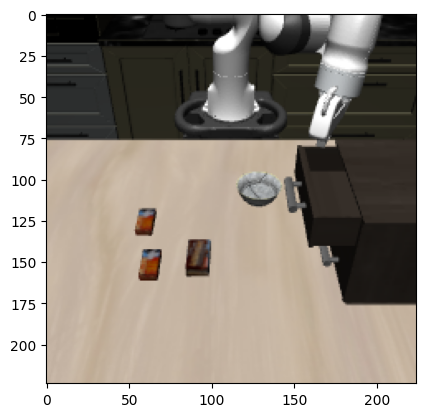

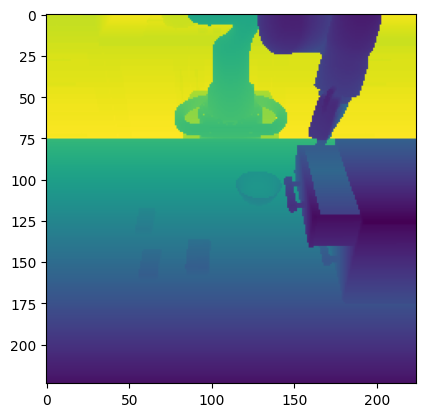

NameError: name 'freq' is not defined

In [37]:
task = "Stack the red cube onto the green cube."

import math
def get_cam_pose(env, cam_name="agentview"):
    cam_id = env.sim.model.camera_name2id(cam_name)
    return (env.sim.model.cam_pos[cam_id], env.sim.model.cam_quat[cam_id])
    
def set_cam_pose(env, pose, cam_name="agentview"):
    cam_id = env.sim.model.camera_name2id(cam_name)
    env.sim.model.cam_pos[cam_id] = pose[0]
    env.sim.model.cam_quat[cam_id] = pose[1]

for instance in libero_envs.task_instantiations(0):
    obs, env, task_description = instance
    # prev_pos, prev_quat = save_cam_pose
    # set_cam_pose(env, (prev_pos+[0, 0, 1], prev_quat))
    # obs, reward, done, info = env.step(np.zeros(7))
    # break
    prompt = prompt_from_obs(obs, task_description)
    vla_output = policy.infer(prompt)
    actions = vla_output['actions']
    print(vla_output.get('subtask', 'no subtask output'), flush=True)
    rollout.append(obs)

    policy_infer = prof.profiled(policy.infer, name="infer")

    trajectory_idx = 0
    for i in range(200):
        act = np.copy(actions[trajectory_idx])
        act[-1] *= 1
        obs, reward, done, info = env.step(act)
        rollout.append(obs)
        frames.append(obs['agentview_image'][::-1, ::-1, :])
        wrist_frames.append(obs['robot0_eye_in_hand_image'][::-1, ::-1, :])
        trajectory_idx += 1
        if trajectory_idx == (len(actions)//2):
            prompt = prompt_from_obs(obs, task_description)
            vla_output = policy_infer(prompt)
            actions = vla_output['actions']
            print(vla_output.get('subtask', 'no subtask output'), flush=True)
            trajectory_idx = 0

#save_cam_pose = get_cam_pose(env)
print(task_description)
img = obs['agentview_image'][::-1, ::-1, :]
import matplotlib.pyplot as plt
plt.figure(0)
plt.clf()
plt.imshow(img)
plt.figure(1)
plt.clf()
plt.imshow(obs['agentview_depth'][::-1, ::-1, :])
plt.show()
media.write_video(f'franka_90.mp4', frames, fps=freq)
media.write_video(f'franka_90_wrist.mp4', wrist_frames, fps=freq)

### Running with VLM verification in the loop

Not exactly like Verytrace.
The outer loop (plan loop) is being handled completely by one instance of Gemma3, which is making a tool call to command the VLA to take an action (`execute_action` function.).
The planner VLM is also told to explain its plan through the arguments to the function.
The simulator runs for a fixed number of steps, then the verifier VLM is given the function arguments and final robot state (as an image).
The verifier checks if the intent is reflected in the image, and returns the result (SUCCESS, IN_PROGRESS, or FAILURE) to the planner.

This first cell can take a long time to run, since it jit compiles the inference function.

In [ ]:
policy_infer = prof.profiled(policy.infer, name="infer")

obs = None
observed_image = None
env = None

@prof.profiled
def env_step(actions):
    return env.step(actions)

@tool_wrap(ImageResponse)
def get_robot_image() -> ImageResponse:
    """
    Get the image the robot is currently seeing.
    Use this at the start of a task, to understand what the camera sees.
    """
    return observed_image

def verify(image, action, postcondition):
    verifier_prompt = """
    You are a careful AI assistant auditing a robot. The robot was told to perform a series of actions,
    but it is error prone. One action in this series is shown to you, intended to complete a subtask.
    Your job is to decide if the action was successfully executed or not.

    You should return a json string, of the form:

    ```json
    {
      "status": ["OK"|"IN_PROGRESS"|"FAILURE"],
      "reason": "put reasoning here"
    }
    ```

    Status should be:
     - OK if the execution succeeded fully.
     - IN_PROGRESS if it looks like the execution is on track to succeed.
       For example, if the subtask is to pick up an object and the robot is near the object but not grasped yet.
     - FAILURE if the subtask failed, for example the robot picked up the wrong object.

    Also supply the reason for your decision.
    """
    messages = [
        {'role': 'system', 'content': verifier_prompt},
        {
            'role': 'user',
            'content': f"The action was: {action}, the subgoal is: {postcondition}",
            'images': [ImageResponse.encode_image(image)]
        }
    ]
    while True:
        resp = client.chat(model=model_name, stream=False, messages=messages,
            keep_alive=-1,
            options=dict(
                num_ctx=context_length,
                temperature=0.0
            )
        )
        resp_str = resp.message.content
        if "```json" not in resp_str:
            print("Verification failed... retry")
            messages.append({'role': 'user', 'content': "I don't see an answer..."})
            continue
        end = resp_str.split('```json', 1)[1].replace('```', '').strip()
        print("Verification result:", end)
        return end

#@tool_wrap(ImageResponse)
def execute_action(action: str, postcondition: str) -> ImageResponse:
    """
    Attempt to execute a short action from the robot.

    Arguments:
        action: The action to execute. This should be a short, "single step" action.
        postcondition: Condition to be satisfied at the end of this action. For example, "robot is holding cup"

    Return: New image of the scene after robot has attempted action execution, along with status message (sucess or failure)
    """
    global obs, observed_image
    
    prompt = prompt_from_obs(obs, action)
    vla_output = policy.infer(prompt)
    actions = vla_output['actions']
    #print(vla_output.get('subtask', 'no subtask output'), flush=True)

    trajectory_idx = 0
    for i in range(100):
        act = np.copy(actions[trajectory_idx])
        act[-1] *= 1
        obs, reward, done, info = env_step(act)
        prompt = prompt_from_obs(obs, action)
        rollout.append(prompt['observation/state'])
        frames.append(obs['agentview_image'][::-1, ::-1, :])
        wrist_frames.append(obs['robot0_eye_in_hand_image'][::-1, ::-1, :])
        trajectory_idx += 1
        if trajectory_idx == (len(actions)//2):
            vla_output = policy_infer(prompt)
            actions = vla_output['actions']
            #print(vla_output.get('subtask', 'no subtask output'), flush=True)
            trajectory_idx = 0
    observed_image = frames[-1]
    snapshots.append(observed_image)
    msg = verify(observed_image, action, postcondition)
    statuses.append(msg)
    subtasks.append((action, postcondition))
    return ImageResponse(img=observed_image, message=msg)

tool_handler = ToolHandler()
tool_handler.register(get_robot_image)
tool_handler.register(execute_action)

llm_prompt = """
You are a careful AI assistant controlling a robot using natural language.
You have control over a rudimentary low-level controller that can be comamnded by short natural language commands.
When given a task, you should break it down into steps, and use `execute_action` to execute the steps one by one,
checking that the execution succeeded by reading its return output.

If the execution did not succeed, try to interpret the error message given. Sometimes, you may just need to
execute the same task again (for longer tasks); sometimes you may need to try a different approach.
For example, if the robot picked up the wrong object, you may have to tell it to put down the object it's holding
before picking up the correct object. Or, you can try identifying the object in different ways, such as by position, size,
or color.

If you get an IN_PROGRESS status, you should reissue the same command, until a success or failure status is read.
If the episode terminated, don't try to restart it. Just tell the user you couldn't complete the task and terminate.

When you are done with the task, simply tell the user they are done by emitting the string "Done".
"""

### Manually running the "verified" loop

Pretty easy, LLM handles tool calling.
Next cell is result visualization

In [ ]:
tool_handler.reset_chat(llm_prompt)
task = "Stack the red cube onto the green cube."
s = chat(task)
print("Final output:", s)

In [ ]:
import matplotlib.pyplot as plt
print(s)
idx = 0
plt.figure(0)
plt.clf()
plt.imshow(snapshots[idx])
print(statuses[idx])
print(subtasks[idx])

### Run multiple trials and save the results

Result videos, and observations/verifier and planner traces in a pickle file

In [ ]:
import pickle

def run_one_trial(trial_idx):
    global env
    global obs, observed_image
    global rollout, frames, wrist_frames, snapshots, statuses, subtasks
    rollout = []
    frames = []
    wrist_frames = []
    snapshots = []
    statuses = []
    subtasks = []

    # TODO: iterate through both levels
    for instance in libero_envs.task_instantiations(trial_idx):
        obs, env, task_description = instance
        break
    observed_image = obs['agentview_image'][::-1, ::-1, :]
    tool_handler.reset_chat(llm_prompt)
    s = chat(f"Please {task_description}.")
    frames.append(observed_image)
    wrist_frames.append(obs['robot0_eye_in_hand_image'][::-1, ::-1, :])

    with open(f"output/franka_libero.{trial_idx}.pkl", "wb") as outfile:
        pickle.dump({
            "snapshots": snapshots,
            "statuses": statuses,
            "subtasks": subtasks,
            "state_traj": rollout
        }, outfile)
    media.write_video(f'output/franka_libero.{trial_idx}.mp4', frames, fps=20)
    media.write_video(f'output/franka_libero_wrist.{trial_idx}.mp4', wrist_frames, fps=20)

In [ ]:
for i in range(1, 60):
    print(f"Running trial {i}")
    run_one_trial(i)

In [21]:
# Profiling information
prof.prof_dump_info()

Total time: 7831.230517625809
> Function prompt_from_obs
           |       Time |    Calls |     Average |         Min |         Max | Thread Info
           |    0.200264 |    6870 |  0.00002915 |  0.00001984 |  0.00019620 | MainThread
<< Totals: |  0.20026445 |    6870 |  0.00002915 |  0.00001984 |  0.00019620 | 1 threads
> Function infer
           |       Time |    Calls |     Average |         Min |         Max | Thread Info
<< Totals: |  0.00000000 |       0 |  0.00000000 | 1000000000.00000000 |  0.00000000 | 0 threads
> Function infer
           |       Time |    Calls |     Average |         Min |         Max | Thread Info
<< Totals: |  0.00000000 |       0 |  0.00000000 | 1000000000.00000000 |  0.00000000 | 0 threads
> Function infer
           |       Time |    Calls |     Average |         Min |         Max | Thread Info
<< Totals: |  0.00000000 |       0 |  0.00000000 | 1000000000.00000000 |  0.00000000 | 0 threads
> Function env_step
           |       Time |    Calls |  

In [ ]:
media.write_video(f'output/franka_libero.{0}.mp4', frames, fps=20)
media.write_video(f'output/franka_libero_wrist.{0}.mp4', wrist_frames, fps=20)

In [ ]:
# Manual chat
client.chat(model=model_name, messages=[{'role': 'user', 'content': 'hello'}], stream=False)